<a href="https://colab.research.google.com/github/chamarairesh1982/LearnPython/blob/main/week_10_Clustering_Practical_Wine_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Clustering Algorithms and Evaluation using Wine Dataset

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, BisectingKMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

## Load Dataset
Dataset Information: https://www.geeksforgeeks.org/machine-learning/wine-dataset/

In [2]:
wine=load_wine()
X=pd.DataFrame(wine.data,columns=wine.feature_names)
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## Scale Features
Important: Distance-based clustering requires scaling.

In [3]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

## PCA for Visualization
Reduce all the original features in the dataset to 2 principal components.

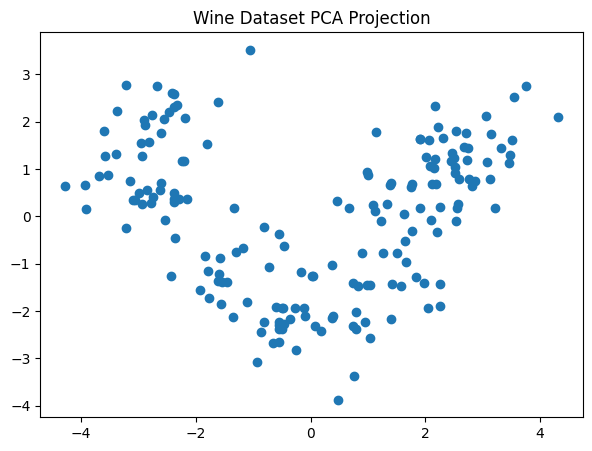

In [4]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0],X_pca[:,1])
plt.title("Wine Dataset PCA Projection")
plt.show()

# K-Means
Hyperparameter: n_clusters

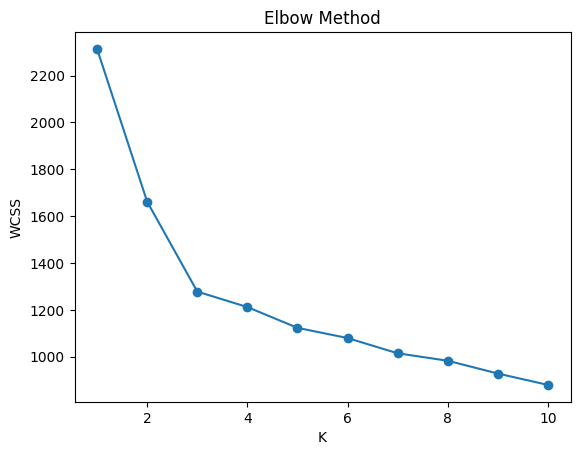

In [5]:
wcss=[]
for k in range(1,11):
    model=KMeans(n_clusters=k,random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)
plt.plot(range(1,11),wcss,marker="o")
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

In [6]:
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans_labels=kmeans.fit_predict(X_scaled)

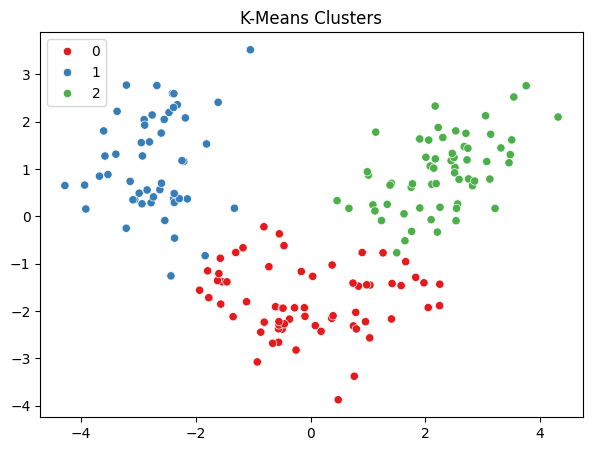

In [7]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=kmeans_labels,palette="Set1")
plt.title("K-Means Clusters")
plt.show()

# Agglomerative Hierarchical Clustering
Hyperparameters: n_clusters, linkage

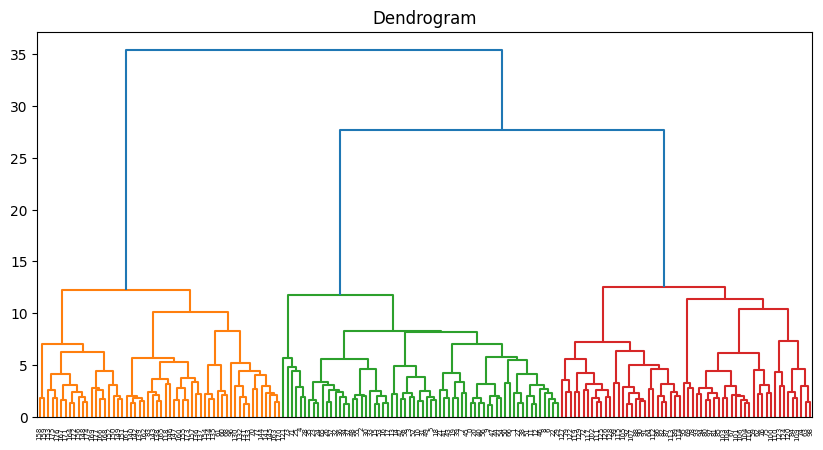

In [8]:
plt.figure(figsize=(10,5))
dendrogram(linkage(X_scaled,method="ward"))
plt.title("Dendrogram")
plt.show()

In [9]:
agg=AgglomerativeClustering(n_clusters=3,linkage="ward")
agg_labels=agg.fit_predict(X_scaled)

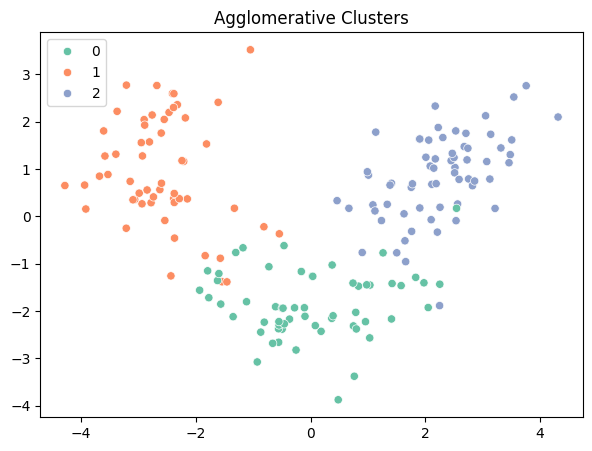

In [10]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=agg_labels,palette="Set2")
plt.title("Agglomerative Clusters")
plt.show()

# Divisive Hierarchical Clustering
Using BisectingKMeans approximation. Hyperparameter: n_clusters

In [11]:
divisive=BisectingKMeans(n_clusters=3,random_state=42)
div_labels=divisive.fit_predict(X_scaled)

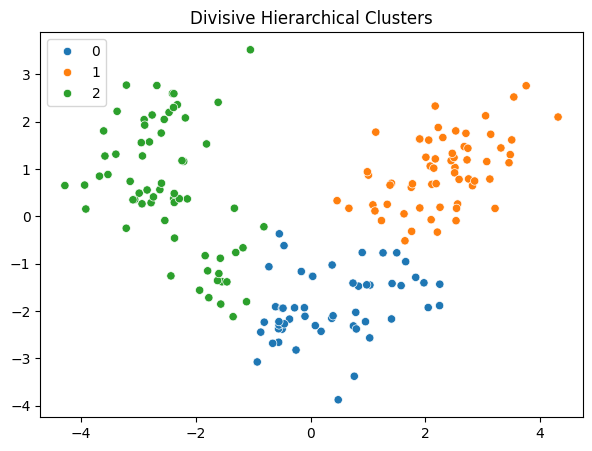

In [12]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=div_labels,palette="tab10")
plt.title("Divisive Hierarchical Clusters")
plt.show()

# DBSCAN
Hyperparameters: eps, min_samples. Noise points get label -1.

In [13]:
dbscan=DBSCAN(eps=3.0,min_samples=5)
db_labels=dbscan.fit_predict(X_scaled)

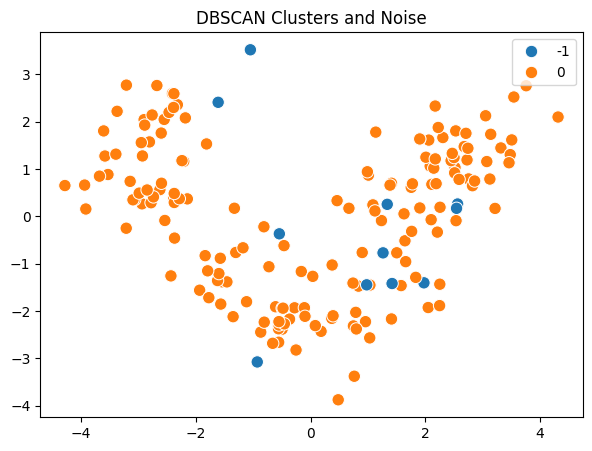

Unique cluster labels: {np.int64(0), np.int64(-1)}


In [14]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=db_labels,palette="tab10", s=80)
plt.title("DBSCAN Clusters and Noise")
plt.show()
print("Unique cluster labels:",set(db_labels))

## Evaluation Metrics

In [15]:
def evaluate(X,labels):
    if len(set(labels))<2:
        return [None,None,None]
    return [silhouette_score(X,labels),calinski_harabasz_score(X,labels),davies_bouldin_score(X,labels)]

k_s,k_c,k_d=evaluate(X_scaled,kmeans_labels)
a_s,a_c,a_d=evaluate(X_scaled,agg_labels)
d_s,d_c,d_d=evaluate(X_scaled,div_labels)
mask=db_labels!=-1
b_s,b_c,b_d=evaluate(X_scaled[mask],db_labels[mask])

In [16]:
results=pd.DataFrame({
"Algorithm":["K-Means","Agglomerative","Divisive","DBSCAN"],
"Silhouette":[k_s,a_s,d_s,b_s],
"Calinski-Harabasz":[k_c,a_c,d_c,b_c],
"Davies-Bouldin":[k_d,a_d,d_d,b_d]})
results

,Algorithm,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means,0.284859,70.940008,1.389188
1,Agglomerative,0.277444,67.647468,1.418592
2,Divisive,0.265949,66.372482,1.429707
3,DBSCAN,NaN,NaN,NaN
